# Exercise sheet 2: Supervised Regression

In [1]:
# label: import
# Consider the following libraries for this exercise sheet:

# general
import numpy as np
import pandas as pd
import math
# plots
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import sklearn.metrics as metrics
from sklearn.metrics import mean_absolute_error

## Exercise 1: HRO

Throughout the lecture, we will frequently use the Python package `sklearn`, and its descendants, providing an integrated ecosystem for all common machine learning tasks. Let’s recap the HRO
principle and see how it is reflected in `sklearn`.<br>
An overview of the most important objects andtheir usage, illustrated with numerous examples, can be found at __[https://scikit-learn.org/stable/index.html](https://scikit-learn.org/stable/index.html)__.

> a) How are the key concepts (i.e., hypothesis space, risk and optimization) you learned about in the lecture videos
implemented?

> **\# Enter your answer here:** Trong sklearn, **hypothesis space** được xác định bởi các class mô hình và siêu tham số (vd: LinearRegression, DecisionTree, KNN). **Risk** được định nghĩa qua loss functions hoặc metrics (vd: MSE, log-loss, accuracy). **Optimization** là các thuật toán được sklearn triển khai (vd: least squares, gradient descent, tree splitting) để tìm mô hình tối ưu.

> b) Have a look at `sklearn.datasets import load_iris`. What attributes does this
object store?

In [2]:
# Enter your code here:
from sklearn.datasets import load_iris
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

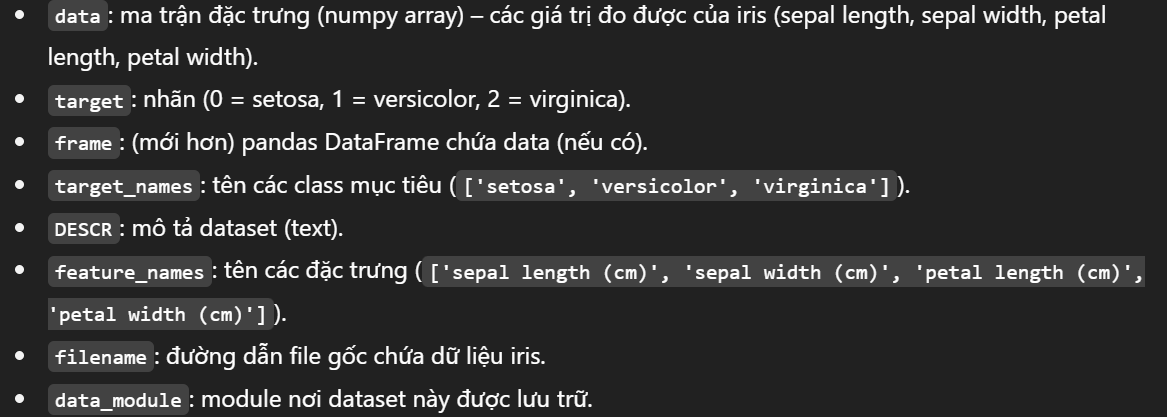

> c) Instantiate a regression tree learner (`DecisionTreeRegressor`). What are the different settings for this learner?

<div class="alert alert-block alert-info">
<b>Hint:</b> Import the specific module and use <code>get_params()</code> to see all available settings.
</div>

In [3]:
# Enter your code here:
reg = DecisionTreeRegressor()
reg.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

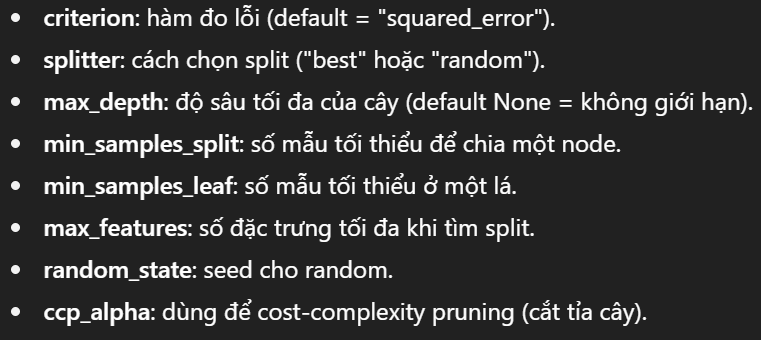

## Exercise 4: Predicting `abalone`

We want to predict the age of an abalone using its longest shell measurement and its weight. <br>

In [5]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data" #path to the dataset
abalone = pd.read_csv(url, sep=",",
names=["sex", "longest_shell", "diameter", "height", "whole_weight",
"shucked_weight", "visceral_weight", "shell_weight", "rings"])
abalone = abalone[["longest_shell", "whole_weight", "rings"]]

In [6]:
print("✅ Dataset loaded successfully!")
print(f"Shape: {abalone.shape}")
print("\nFirst 5 rows:")
print(abalone.head())

✅ Dataset loaded successfully!
Shape: (4177, 3)

First 5 rows:
   longest_shell  whole_weight  rings
0          0.455        0.5140     15
1          0.350        0.2255      7
2          0.530        0.6770      9
3          0.440        0.5160     10
4          0.330        0.2050      7


> a) Plot `LongestShell` and `WholeWeight` on the x- and y-axis, respectively, and color points according to `Rings`.

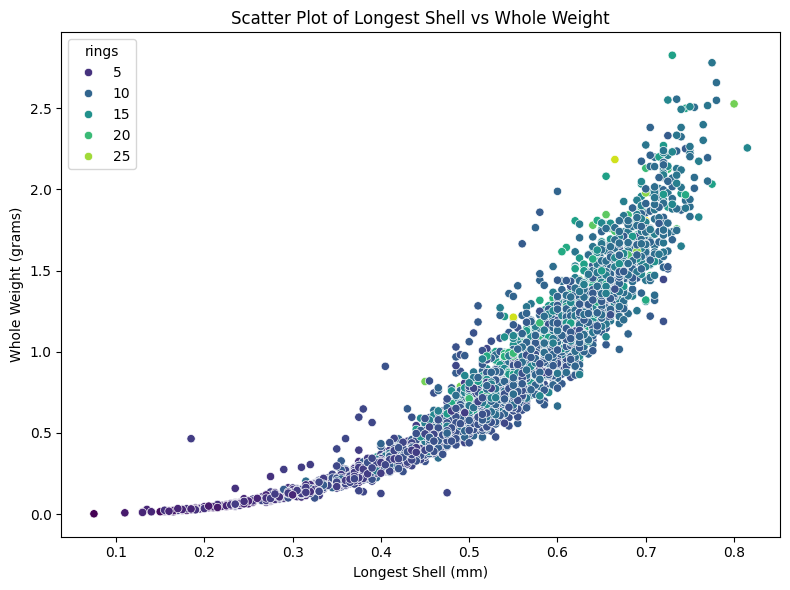

In [15]:
# Enter your code here:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=abalone, x="longest_shell", y="whole_weight", hue="rings", palette="viridis")
plt.title("Scatter Plot of Longest Shell vs Whole Weight")
plt.xlabel("Longest Shell (mm)")
plt.ylabel("Whole Weight (grams)")
plt.tight_layout()
plt.show()

> b) Using `sklearn`, fit a linear regression model to the data.

In [25]:
# Enter your code here:
from sklearn.model_selection import train_test_split

X, y = abalone.drop(columns=["rings"]), abalone["rings"]

X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

> c) Compare the fitted and observed targets visually.

<div class="alert alert-block alert-info">
<b>Python:</b> use <code>import matplotlib.pyplot as plt</code>.
</div>

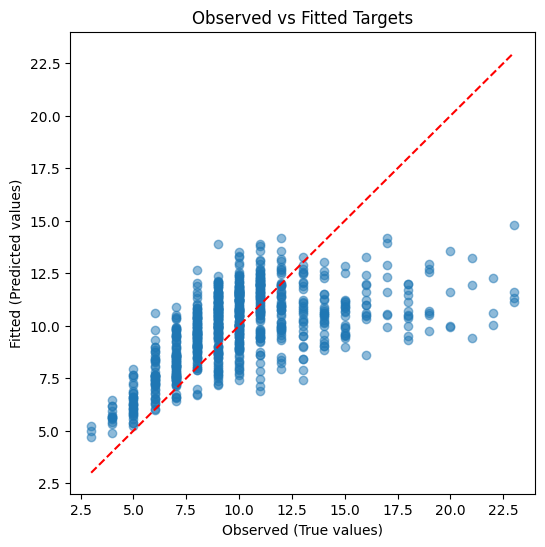

In [28]:
# Enter your code here:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # đường chéo
plt.xlabel("Observed (True values)")
plt.ylabel("Fitted (Predicted values)")
plt.title("Observed vs Fitted Targets")
plt.show()


> d) Assess the model’s training loss in terms of MAE.

<div class="alert alert-block alert-info">
<b>Python Hint:</b> The MAE metric is retrieved by calling <code>from sklearn.metrics import mean_absolute_error</code>.
</div>

In [29]:
# Enter your code here:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.952370229060179


![abalone.JPG](attachment:abalone.JPG)

__[https://en.wikipedia.org/wiki/Abalone#/media/File:LivingAbalone.JPG](https://en.wikipedia.org/wiki/Abalone#/media/File:LivingAbalone.JPG)__